In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as INT



In [31]:
def repetitive_stim_maker(num_repeat,total_time,off_first = False):
    '''
    num_repeat: number of segments each made of repetitive cycles (e.g., if 2, [11110000])\\
    total_time: span of the stimulation experiment. For example, if 20, it means 20 cycles (and for a 5 min stim sampling, 100 mins).\\
    off_first: bool whether stim starts with off signal or not. Defaults is False.\\
    **Example**:\\
    num_repeat = 4 and total_time = 60 means [[15 ones and 15 zeros, 15 ones and 15 zeros]
    '''
    num_reps = int(np.floor(total_time/num_repeat))
    ons = np.repeat(1,num_reps)
    offs = np.repeat(0,num_reps)
    tile = np.hstack((offs,ons)) if off_first else np.hstack((ons,offs)) 
    stim_vec = np.tile(tile,int(num_repeat))
    stim_vec = stim_vec[:total_time]
    return stim_vec


In [108]:
def rxn1(x,t,params,stim_vec):
    alpha , k , n , tau_delay , h1 , h2 ,c2 , delta = params
    H,E,F = x
    U = stim_vec[int(t/5)]
    L = ((c2*H)**n)/(k + (c2*H)**n)
    return [
        U- c2*H,
        h1 - h2*E,
        alpha * E * L - delta * F
    ]
    
def rxn2(x,t,params,params_tet,stim_vec):
    alpha , k , n , tau_delay , h1 , h2 ,c2 , delta_T = params
    alpha , beta, k_tet , k , n ,n_tet, tau_delay , h1 , h2 , c2,delta = params_tet
    H,E,T,F = x
    U = stim_vec[max(int((t-tau_delay)/5),0)]
    L = ((c2*H)**n)/(k + (c2*H)**n)
    return [
        U- c2*H,
        h1 - h2*E,
        alpha * E * L - delta_T * T,
        beta*E/(1+(T/k_tet)**n_tet) - delta * F
    ]

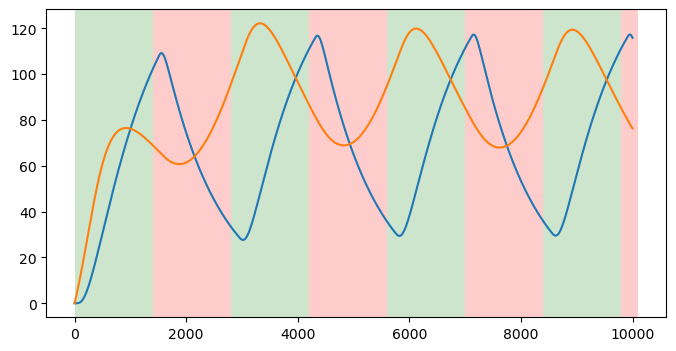

In [111]:
delta = 0.01
alpha = 1
beta = 1
k = 0.4851
k_tet = 50
h1 = 2.3435*0.0303
h2 = 0.0303
tau_delay = 12
n=3.6
n_tet = 2
c2 = 0.0631
params = [alpha , k , n , tau_delay , h1 , h2 ,c2 , delta]
params_tet = [alpha , beta, k_tet , k , n ,n_tet, tau_delay , h1 , h2 , c2,delta]


t = np.linspace(0,1000,10000)
x0 = [0,round(np.random.poisson(h1/h2)),0,0]
stim_vec = repetitive_stim_maker(7,int(1000/5)+2)
sol = INT.odeint(rxn2,x0,t,args = (params,params_tet,stim_vec))

fig, ax = plt.subplots(figsize=(8, 4))
for i, val in enumerate(stim_vec):
        x_start =  i * 50
        x_end = x_start + 50
        color = 'green' if val == 1 else 'red'
        ax.axvspan(x_start, x_end, facecolor=color, alpha=0.2)

plt.plot(sol[:,2])
plt.plot(sol[:,3])
plt.show()